# 04. 분석 질문과 가설 검증

[01 문제 정의와 가설](01_problem_hypothesis.md)에서 정의한 두 분석 질문과 세 가설을 검증한다. [02 데이터 전처리·ETL](02_data_preparation.ipynb)이 MySQL에 적재하고 [03 데이터 개요](03_data_overview.ipynb)에서 소개한 응답을 [최종 SQL](../sql/04_eda_validation.sql)로 조회한다. 분석 질문 1에서는 추천 의향과 지속 이용 의향·자기보고 구매 활동의 관계를, 분석 질문 2에서는 최초 인지 채널과 최근 구매 영향 채널의 연결을 확인한다. 이후 Q13·Q18로 반복되는 사용자 불편을 탐색한다.

---
## 1. 분석 대상과 분모

원본 269건에서 논리 모순 3건을 제외한 정제 응답은 266건이다. H1·Q13은 플랫폼 사용자 200명, H2는 그중 최근 6개월 구매자 191명, H3는 공통 3채널 인지자 155명을 대상으로 한다. Q18은 유효 자유응답 전체 92건을 기준으로 보고, 그중 플랫폼 사용자 68건은 Q13과 연결할 때 함께 확인한다.

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from dotenv import load_dotenv
from sqlalchemy import URL, create_engine
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

pio.renderers.default = 'plotly_mimetype'
COLORS = {'positive': '#10B981', 'attention': '#EF4444',
          'view': '#3B82F6', 'cart': '#F59E0B', 'neutral': '#94A3B8'}

def find_project_root():
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if ((candidate / 'notebooks').is_dir()
                and (candidate / 'sql').is_dir()
                and (candidate / 'data' / 'q18_audited_labels.csv').is_file()):
            return candidate
    raise FileNotFoundError(f'프로젝트 루트를 찾지 못했습니다: {start}')

ROOT = find_project_root()
load_dotenv(ROOT / '.env')
required = ('DB_USER', 'DB_PASSWORD', 'DB_HOST', 'DB_NAME')
missing = [key for key in required if not os.getenv(key)]
if missing:
    raise RuntimeError(f'MySQL 환경변수 누락: {", ".join(missing)}')
url = URL.create(
    'mysql+mysqlconnector', username=os.environ['DB_USER'],
    password=os.environ['DB_PASSWORD'], host=os.environ['DB_HOST'],
    database=os.environ['DB_NAME'],
)
engine = create_engine(url, pool_pre_ping=True)

def load_queries(path):
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(ROOT / 'sql' / '04_eda_validation.sql')
def run(name):
    return pd.read_sql(Q[name], engine)

population = run('population').iloc[0]
users = run('users')
buyers = run('buyers')
# 단일 플랫폼을 지정하지 않은 설문이므로 집단 라벨도 추천 의향 표현으로 읽는다 (01과 같은 표기).
# SQL 뷰의 nps_segment 정의는 그대로 두고 조회 결과만 바꾼다.
SEGMENT_KO = {'Detractor': '비추천자', 'Passive': '중립', 'Promoter': '추천자'}
users['nps_segment'] = users['nps_segment'].map(SEGMENT_KO)
buyers['nps_segment'] = buyers['nps_segment'].map(SEGMENT_KO)
q13 = run('q13_base')
q13['selection'] = q13['dissatisfaction'].str.split(', ')
q13 = q13.explode('selection').drop(columns='dissatisfaction')
q13['selection'] = q13['selection'].str.strip()
q13 = q13.dropna(subset=['selection']).reset_index(drop=True)
q18 = run('q18_labeled')
q18_n = q18['user_id'].nunique()
q18_user = q18.loc[q18['is_platform_user'].eq(1)]
q18_user_n = q18_user['user_id'].nunique()
assert (len(users), len(buyers), q13['user_id'].nunique(), q18_n, q18_user_n) == (200, 191, 200, 92, 68)
assert int(population['h3_channel_n']) == 155
assert users[['nps', 'nps_segment', 'continue_score']].notna().all().all()
assert buyers[['frequency_score', 'recency_score']].notna().all().all()
display(pd.DataFrame([
    ['원본 설문', int(population['raw'])],
    ['논리 모순 제거 후', int(population['cleaned'])],
    ['플랫폼 사용자 · H1/Q13', len(users)],
    ['최근 6개월 구매자 · H2', len(buyers)],
    ['공통 3채널 인지자 · H3', int(population['h3_channel_n'])],
    ['Q18 유효 자유응답 · 전체', q18_n],
    ['Q18 중 플랫폼 사용자 · 보조', q18_user_n],
], columns=['분석 대상', 'n']))

,분석 대상,n
0,원본 설문,269
1,논리 모순 제거 후,266
2,플랫폼 사용자 · H1/Q13,200
3,최근 6개월 구매자 · H2,191
4,공통 3채널 인지자 · H3,155
5,Q18 유효 자유응답 · 전체,92
6,Q18 중 플랫폼 사용자 · 보조,68


---
## 2. 분석 질문 1 — 추천 의향은 지속 이용 의향 및 자기보고 구매 활동과 얼마나 일치하는가?

### 가설 1. 추천 의향과 지속 이용 의향

**가설:** 추천 의향이 높을수록 지속 이용 의향도 높을 것이다.

> **Q14.** 지금 가장 자주 사용하는 플랫폼을 앞으로도 계속 사용할 것 같나요? `5단계`  
> **Q15.** 현재 사용하는 패션 플랫폼을 지인에게 추천할 의향이 얼마나 있나요? `0~10점`

#### 분석 기준

Q15의 0–10점과 Q14의 5단계 의향을 비교한다. 긍정 지속 의향은 ‘아마 사용할 것 같다’ 또는 ‘계속 사용할 것 같다’다. NPS Score는 추천자 비율에서 비추천자 비율을 뺀 값이다.

In [2]:
segment_order = ['비추천자', '중립', '추천자']
cross = pd.crosstab(users['nps_segment'], users['is_retain_positive']).reindex(
    index=segment_order, columns=[0, 1], fill_value=0
)
cross.columns = ['그 외', '긍정 지속 의향']
cross.index.name = '추천 의향 집단'
cross['계'] = cross.sum(axis=1)
cross['긍정 비율(%)'] = (cross['긍정 지속 의향'] / cross['계'] * 100).round(1)

nps_score = (users['nps_segment'].eq('추천자').mean() - users['nps_segment'].eq('비추천자').mean()) * 100
positive_n = int(users['is_retain_positive'].sum())
detractor_positive = int(cross.loc['비추천자', '긍정 지속 의향'])
detractor_n = int(cross.loc['비추천자', '계'])
rho_h1, p_h1 = stats.spearmanr(users['nps'], users['continue_score'])
chi2_h1, p_chi_h1, _, expected_h1 = stats.chi2_contingency(cross[['그 외', '긍정 지속 의향']])
cramers_v_h1 = np.sqrt(chi2_h1 / len(users))
assert abs(nps_score - (-32.0)) < 0.0001
assert abs(rho_h1 - 0.4002) < 0.0001
assert abs(chi2_h1 - 9.5933) < 0.0001
assert abs(cramers_v_h1 - 0.2190) < 0.0001

print(f'NPS Score = {nps_score:.1f}')
print(f'긍정 지속 의향 = {positive_n}/{len(users)} ({positive_n/len(users):.1%})')
print(f'비추천자 긍정 지속 의향 = {detractor_positive}/{detractor_n} ({detractor_positive/detractor_n:.1%})')
print(f'Q15 × Q14: Spearman ρ={rho_h1:.3f}, p={p_h1:.4g}')
print(f'보조 교차표: χ²={chi2_h1:.3f}, p={p_chi_h1:.4f}, Cramér V={cramers_v_h1:.3f}; 기대빈도 <5 셀 {(expected_h1 < 5).sum()}개')
display(cross)

NPS Score = -32.0
긍정 지속 의향 = 187/200 (93.5%)
비추천자 긍정 지속 의향 = 77/88 (87.5%)
Q15 × Q14: Spearman ρ=0.400, p=4.335e-09
보조 교차표: χ²=9.593, p=0.0083, Cramér V=0.219; 기대빈도 <5 셀 1개


,그 외,긍정 지속 의향,계,긍정 비율(%)
추천 의향 집단,,,,
비추천자,11,77,88,87.5
중립,1,87,88,98.9
추천자,1,23,24,95.8


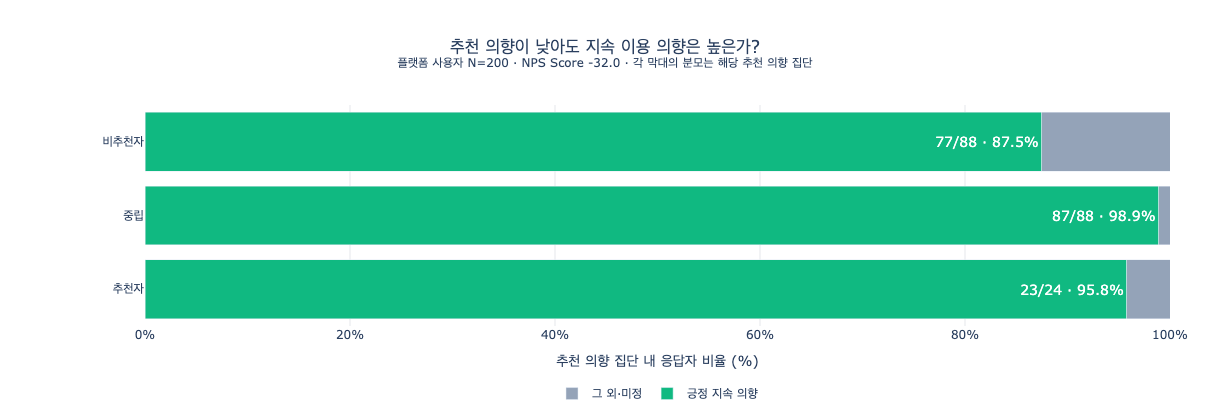

In [3]:
positive_pct = cross.loc[segment_order, '긍정 비율(%)']
other_pct = 100 - positive_pct
fig = go.Figure()
fig.add_trace(go.Bar(
    y=segment_order, x=positive_pct, orientation='h',
    name='긍정 지속 의향', marker_color=COLORS['positive'],
    text=[f"{int(cross.loc[s, '긍정 지속 의향'])}/{int(cross.loc[s, '계'])} · {positive_pct[s]:.1f}%" for s in segment_order],
    textposition='inside', textfont=dict(color='white', size=14),
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.add_trace(go.Bar(
    y=segment_order, x=other_pct, orientation='h',
    name='그 외·미정', marker_color=COLORS['neutral'],
    hovertemplate='%{y}<br>그 외·미정 %{x:.1f}%<extra></extra>',
))
fig.update_layout(
    barmode='stack',
    title=dict(text=f'추천 의향이 낮아도 지속 이용 의향은 높은가?<br><sup>플랫폼 사용자 N={len(users)} · NPS Score {nps_score:.1f} · 각 막대의 분모는 해당 추천 의향 집단</sup>', x=0.5),
    xaxis=dict(title='추천 의향 집단 내 응답자 비율 (%)', range=[0, 100], gridcolor='#E5E7EB', ticksuffix='%'),
    yaxis=dict(autorange='reversed'),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(orientation='h', y=-0.24, x=0.5, xanchor='center'),
    height=420, width=1050, margin=dict(l=145, r=40, t=105, b=80),
)
fig.show()

추천 의향과 지속 이용 의향은 양의 관계를 보였다(Spearman ρ≈0.400). 플랫폼 사용자 200명의 NPS Score는 −32.0이었고, 187명(93.5%)이 긍정 지속 이용 의향을 답했다. 비추천자 88명 중에서도 77명(87.5%)이 긍정적으로 답했다. 병합 교차표의 카이제곱 검정은 χ²≈9.593, Cramér’s V≈.219였다.

#### 가설 1 결과

가설 1의 관계 방향은 지지됐다. 추천 의향이 높을수록 지속 이용 의향도 높아지는 경향(ρ≈0.400)이 나타났지만, 비추천자 88명 중 77명(87.5%)도 긍정 지속 의향을 답했다. 두 지표는 같은 방향으로 움직이면서도 응답자 수준에서는 완전히 일치하지 않는 패턴을 보였다.

### 가설 2. 추천 의향과 자기보고 구매 활동

**가설:** 추천 의향이 높을수록 자기보고 구매 빈도는 높고 최근 구매 시점은 가까울 것이다.

> **Q9.** 최근 6개월 동안 패션 플랫폼에서 구매한 횟수는 몇 번인가요? `순서형`  
> **Q10.** 패션 플랫폼에서 가장 최근에 구매한 시점은 언제인가요? `순서형`

#### 분석 기준

최근 6개월 구매자 191명의 Q9 빈도와 Q10 최근성을 순서점수로 비교한다. 최근성 점수가 높을수록 최근 구매 시점이 가깝다.

In [4]:
rho_f, p_f = stats.spearmanr(buyers['nps'], buyers['frequency_score'])
rho_r, p_r = stats.spearmanr(buyers['nps'], buyers['recency_score'])
results_h2 = pd.DataFrame([
    ['추천 의향 × 자기보고 구매 빈도(Q9)', len(buyers), rho_f, p_f],
    ['추천 의향 × 자기보고 구매 최근성(Q10)', len(buyers), rho_r, p_r],
], columns=['변수 쌍', 'n', 'Spearman ρ', '양측 p-value'])
assert abs(rho_f - 0.2480) < 0.0001
assert abs(rho_r - 0.1861) < 0.0001
display(results_h2.round({'Spearman ρ': 3, '양측 p-value': 4}))

,변수 쌍,n,Spearman ρ,양측 p-value
0,추천 의향 × 자기보고 구매 빈도(Q9),191,0.248,0.0005
1,추천 의향 × 자기보고 구매 최근성(Q10),191,0.186,0.0100


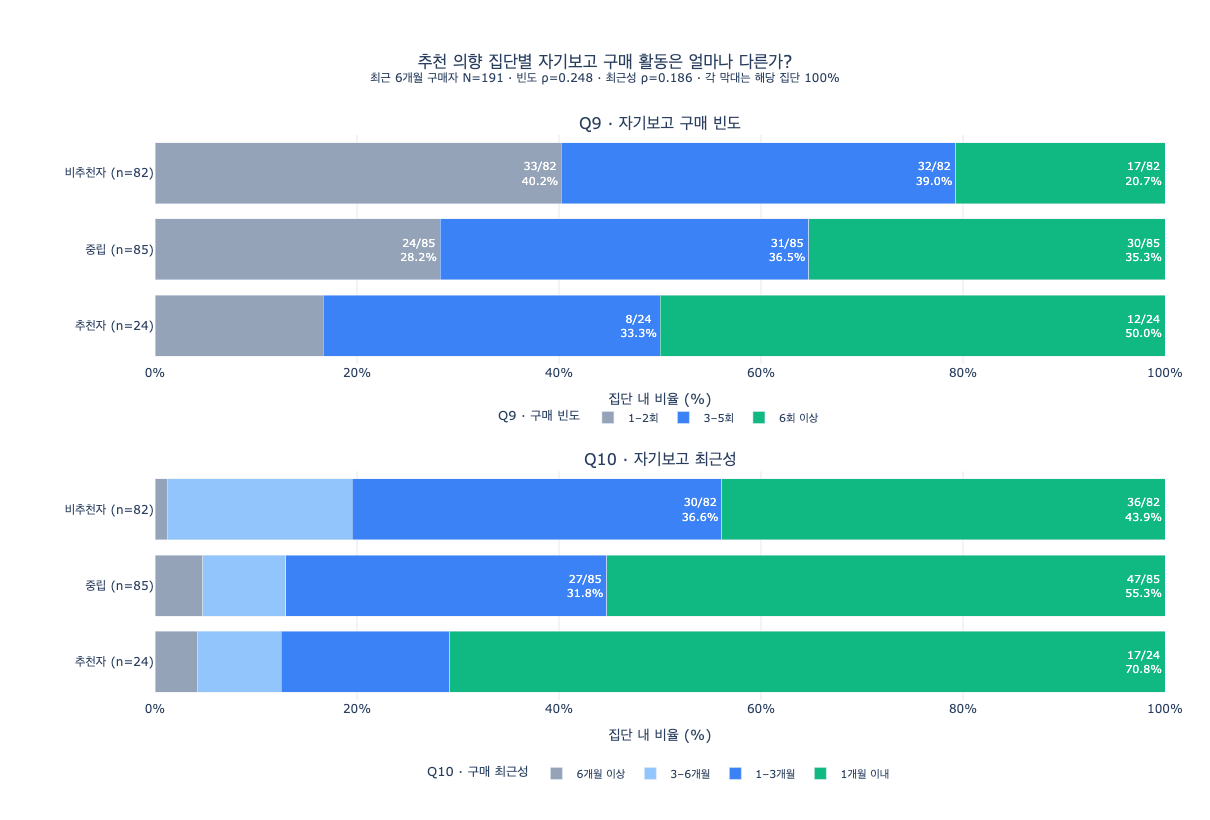

In [5]:
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Q9 · 자기보고 구매 빈도', 'Q10 · 자기보고 최근성'),
    vertical_spacing=0.19,
)
specs = [
    ('frequency_score', [1, 2, 3], ['1–2회', '3–5회', '6회 이상'],
     [COLORS['neutral'], COLORS['view'], COLORS['positive']]),
    ('recency_score', [1, 2, 3, 4], ['6개월 이상', '3–6개월', '1–3개월', '1개월 이내'],
     [COLORS['neutral'], '#93C5FD', COLORS['view'], COLORS['positive']]),
]
for row, (column, order, names, colors) in enumerate(specs, 1):
    table = pd.crosstab(buyers['nps_segment'], buyers[column]).reindex(
        index=segment_order, columns=order, fill_value=0
    )
    shares = table.div(table.sum(axis=1), axis=0).mul(100)
    for score, name, color in zip(order, names, colors):
        label = [
            f'{int(table.loc[segment, score])}/{int(table.loc[segment].sum())}<br>{shares.loc[segment, score]:.1f}%'
            for segment in segment_order
        ]
        fig.add_trace(go.Bar(
            y=segment_order, x=shares[score], orientation='h',
            marker_color=color, name=name, legendgroup=f'{column}-{score}',
            legend='legend' if row == 1 else 'legend2', showlegend=True,
            text=[t if shares.loc[segment, score] >= 19 else '' for segment, t in zip(segment_order, label)],
            textposition='inside', textfont=dict(color='white', size=11),
            customdata=label,
            hovertemplate='%{y}<br>%{customdata}<extra></extra>',
        ), row=row, col=1)
    fig.update_xaxes(title_text='집단 내 비율 (%)', range=[0, 100], gridcolor='#E5E7EB', ticksuffix='%', row=row, col=1)
    fig.update_yaxes(
        autorange='reversed', tickmode='array', tickvals=segment_order,
        ticktext=[f'{segment} (n={int(table.loc[segment].sum())})' for segment in segment_order],
        row=row, col=1,
    )
fig.update_layout(
    barmode='stack',
    title=dict(text=f'추천 의향 집단별 자기보고 구매 활동은 얼마나 다른가?<br><sup>최근 6개월 구매자 N={len(buyers)} · 빈도 ρ={rho_f:.3f} · 최근성 ρ={rho_r:.3f} · 각 막대는 해당 집단 100%</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    legend=dict(
        title='Q9 · 구매 빈도', orientation='h', x=0.5, xanchor='center',
        y=0.50, yanchor='middle', font=dict(size=11),
    ),
    legend2=dict(
        title='Q10 · 구매 최근성', orientation='h', x=0.5, xanchor='center',
        y=-0.13, yanchor='middle', font=dict(size=11),
    ),
    height=820, width=1000, margin=dict(l=155, r=45, t=135, b=120),
)
fig.show()

최근 6개월 구매자 191명에서 추천 의향은 자기보고 구매 빈도(ρ≈0.248)와 최근성(ρ≈0.186)에 모두 양의 관계를 보였다. 두 관계의 크기는 약했고, 추천 의향 집단 간 구매 응답 분포도 넓게 겹쳤다.

#### 가설 2 결과

가설 2는 방향상 지지됐다. 구매 빈도(ρ≈.248)와 최근성(ρ≈.186) 모두 추천 의향과 약한 양의 관계였고, 빈도 쪽 관계가 다소 컸다. 추천 의향 집단별 구매 응답 분포도 넓게 겹쳐, 집단 간 구매 활동이 분명하게 갈라지는 패턴은 아니었다.

---
## 3. 분석 질문 2 — 최초 인지 채널은 최근 구매 영향 채널로도 이어지는가?

### 가설 3. 최초 인지 채널별 동일 채널 응답률

**가설:** 최초 인지 채널에 따라 같은 채널이 최근 구매에도 영향을 줬다고 응답한 비율은 다를 것이다.

Q16은 현재 이용하는 패션 앱을 **처음 알게 된 경로**, Q17은 **최근 6개월 내 구매에 가장 영향을 줬다고 답한 채널**이다. Q16과 Q17의 선택지가 완전히 같지 않아, 두 문항에 공통으로 존재하는 주요 채널인 SNS·유튜브·친구/지인으로 처음 인지한 플랫폼 사용자 155명을 대상으로 비교한다. 두 문항의 표준화 채널명이 같으면 ‘동일 채널’, 다르면 ‘다른 채널’로 구분한다. 검정은 인지 채널 3개 × 동일 채널 여부 2개의 교차표를 사용한다.

In [6]:
# Q16 인지 채널별 동일 채널 응답률과 3×2 교차표를 검정한다.
COMMON_CH = ['SNS', '유튜브', '친구/지인']
channel_match_raw = run('channel_match')
cross_match = (
    channel_match_raw.set_index('인지채널')[['일치', '불일치']]
    .reindex(COMMON_CH).fillna(0).astype(int)
)
assert cross_match.to_dict('index') == {
    'SNS': {'일치':48, '불일치':36},
    '유튜브': {'일치':14, '불일치':9},
    '친구/지인': {'일치':10, '불일치':38},
}
channel_n = int(cross_match.to_numpy().sum())
assert channel_n == int(population['h3_channel_n']) == 155
channel_rates = (cross_match['일치'] / cross_match.sum(axis=1) * 100).round(1)
assert channel_rates.to_dict() == {'SNS':57.1, '유튜브':60.9, '친구/지인':20.8}
chi2_ch, p_ch, dof_ch, expected_ch = stats.chi2_contingency(cross_match)
cramer_v_ch = np.sqrt(chi2_ch / (channel_n * (min(cross_match.shape) - 1)))
assert dof_ch == 2 and (expected_ch < 5).sum() == 0
assert abs(chi2_ch - 18.4468) < 0.0001
assert abs(p_ch - 0.000099) < 0.000001
assert abs(cramer_v_ch - 0.3450) < 0.0001
channel_result = pd.DataFrame({
    '최초 인지 채널 (Q16)': COMMON_CH,
    '인지자 수': cross_match.sum(axis=1).to_numpy(),
    '동일 채널 응답': cross_match['일치'].to_numpy(),
    '동일 채널 비율 (%)': channel_rates.to_numpy(),
})
display(channel_result)
print(f'3×2 교차표: N={channel_n}, χ²={chi2_ch:.3f}, p={p_ch:.6f}, Cramér V={cramer_v_ch:.3f}')

,최초 인지 채널 (Q16),인지자 수,동일 채널 응답,동일 채널 비율 (%)
0,SNS,84,48,57.1
1,유튜브,23,14,60.9
2,친구/지인,48,10,20.8


3×2 교차표: N=155, χ²=18.447, p=0.000099, Cramér V=0.345


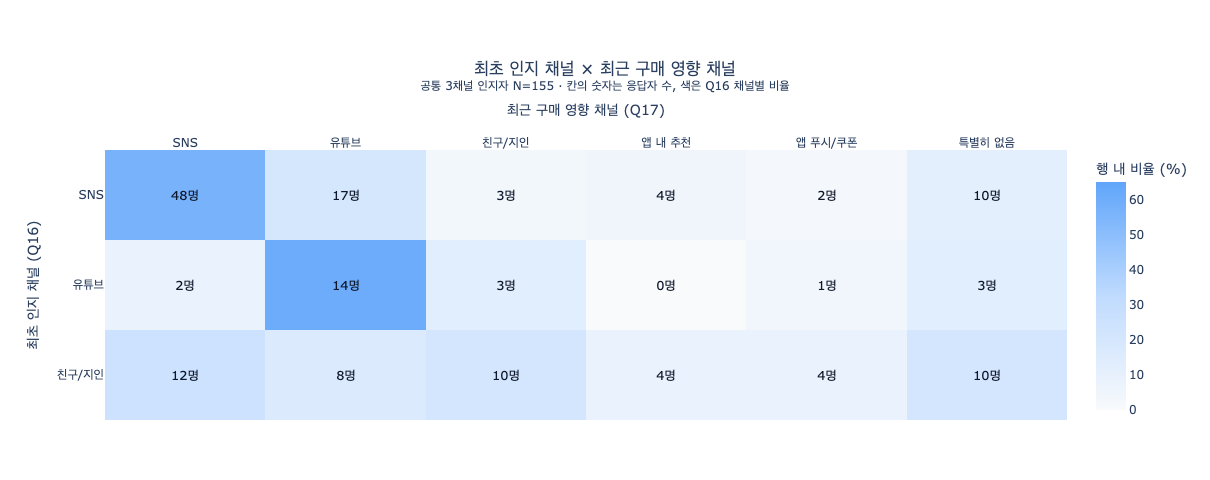

In [7]:
# H3 대상 155명의 인지 × 구매 영향 채널 교차표를 표시한다.
INF_FULL = ['SNS', '유튜브', '친구/지인', '앱 내 추천', '앱 푸시/쿠폰', '특별히 없음']
cross_di = (
    run('channel_cross')
    .pivot(index='discovery', columns='influence', values='n')
    .reindex(index=COMMON_CH, columns=INF_FULL)
    .fillna(0).astype(int)
)
assert cross_di.to_dict('index') == {
    'SNS': {'SNS':48, '유튜브':17, '친구/지인':3, '앱 내 추천':4, '앱 푸시/쿠폰':2, '특별히 없음':10},
    '유튜브': {'SNS':2, '유튜브':14, '친구/지인':3, '앱 내 추천':0, '앱 푸시/쿠폰':1, '특별히 없음':3},
    '친구/지인': {'SNS':12, '유튜브':8, '친구/지인':10, '앱 내 추천':4, '앱 푸시/쿠폰':4, '특별히 없음':10},
}
assert int(cross_di.to_numpy().sum()) == channel_n
assert cross_di.sum(axis=1).to_dict() == cross_match.sum(axis=1).to_dict()
assert all(int(cross_di.loc[ch, ch]) == int(cross_match.loc[ch, '일치']) for ch in COMMON_CH)

# 칸은 응답자 수, 색은 최초 인지 채널(Q16)별 행 비율이다.
cross_di_pct = (cross_di.div(cross_di.sum(axis=1), axis=0) * 100).round(1)
fig = go.Figure(go.Heatmap(
    z=cross_di_pct.to_numpy(), x=INF_FULL, y=COMMON_CH,
    text=[[f'{int(n)}명' for n in row] for row in cross_di.to_numpy()],
    texttemplate='%{text}', textfont=dict(size=13, color='#0F172A'),
    colorscale=[[0, '#F8FAFC'], [0.5, '#BFDBFE'], [1, '#60A5FA']],
    zmin=0, zmax=65, colorbar=dict(title='행 내 비율 (%)'),
    hovertemplate='Q16 %{y} → Q17 %{x}<br>%{text}<br>행 내 비율 %{z:.1f}%<extra></extra>',
))
fig.update_layout(
    title=dict(text=f'최초 인지 채널 × 최근 구매 영향 채널<br><sup>공통 3채널 인지자 N={channel_n} · 칸의 숫자는 응답자 수, 색은 Q16 채널별 비율</sup>', x=0.5),
    xaxis=dict(title='최근 구매 영향 채널 (Q17)', side='top'),
    yaxis=dict(title='최초 인지 채널 (Q16)', autorange='reversed'),
    plot_bgcolor='white', paper_bgcolor='white',
    height=480, width=1000, margin=dict(l=105, r=100, t=150, b=60),
)
fig.show()

같은 채널이 최근 구매에도 영향을 줬다고 응답한 비율은 유튜브 14/23명(60.9%), SNS 48/84명(57.1%), 친구/지인 10/48명(20.8%)이었다. 최초 인지 채널에 따라 동일 채널 응답률에 차이가 있었고, 카이제곱 검정에서도 확인됐다(χ²=18.447, p<.001, Cramér’s V=.345; 기대빈도 5 미만 셀 0개).

#### 가설 3 결과

가설 3은 지지됐다. SNS·유튜브 인지자는 절반 이상이 같은 채널을 최근 구매 영향 채널로도 답한 반면, 친구/지인 인지자는 20.8%였다. 즉 SNS·유튜브는 두 문항에서 다시 언급되는 비율이 상대적으로 높았고, 친구/지인은 최초 인지와 최근 구매 영향의 역할이 더 나뉘는 패턴을 보였다. 이 수치는 두 회상 문항의 응답 연결을 나타내며 실제 유입→구매 로그를 추적한 전환율은 아니다.

---
## 4. 세 가설의 핵심 결과

### H1 · 추천 의향과 지속 이용 의향

두 변수는 양의 관계(ρ≈0.400)였다. 그러나 비추천자에서도 77/88명(87.5%)이 긍정 지속 의향을 보여 두 태도 지표가 완전히 일치하지는 않았다.

### H2 · 추천 의향과 자기보고 구매 활동

두 구매 문항 모두 추천 의향과 양의 관계였지만, 빈도 ρ≈.248·최근성 ρ≈.186으로 연결 정도는 약했다.

### H3 · 최초 인지 채널과 최근 구매 영향 채널

동일 채널 응답률은 유튜브 60.9%, SNS 57.1%, 친구/지인 20.8%였다. 최초 인지와 최근 구매 영향에서 같은 채널이 이어지는 정도는 인지 채널별로 달랐다.

세 가설에서 추천 의향은 지속 이용 의향·자기보고 구매 활동과 같은 방향으로 움직였지만 일치 정도에는 차이가 있었고, 최초 인지와 최근 구매 영향의 채널 연결도 채널별로 달랐다. 사용자 태도·구매 활동·채널 역할을 각각 구분해 보는 것이 적절하다.

---
## 5. 후속 탐색 — 어떤 불편이 반복적으로 나타났는가?

세 가설을 확인한 뒤 선택형 Q13과 자유응답 Q18에서 반복된 불편을 살펴본다. 이 탐색은 다음에 확인할 UX 후보를 찾는 과정이다.

- **Q13:** 플랫폼 사용자 200명의 복수 선택 응답.
- **Q18 전체:** 정제 응답 중 자발적으로 남긴 유효 자유응답 92건. 전수 검토 후 확정한 다중 라벨 CSV(`data/q18_audited_labels.csv`)를 사용하며 한 응답에 여러 유형을 붙일 수 있다.
- **Q18 플랫폼 사용자:** 전체 92건 중 68건. Q13과 사용자 집단을 맞춰 볼 때 함께 확인한다.

In [8]:
# Q13: 플랫폼 사용자 200명 중 각 선택지를 고른 응답자 수
q13_counts = q13.groupby('selection')['user_id'].nunique().sort_values(ascending=False)
assert q13_counts.to_dict() == {
    '사이즈 문제': 102, '실제 상품이 사진과 달랐음': 88, '배송이 느렸음': 48,
    '반품 / 교환 과정이 불편했음': 45, '불만족 경험 없음': 26,
}
q13_table = q13_counts.rename('선택 응답자').to_frame()
q13_table['선택률 (%)'] = (q13_table['선택 응답자'] / len(users) * 100).round(1)
q13_table.index.name = 'Q13 선택지'
assert q13_table.loc['사이즈 문제', '선택률 (%)'] == 51.0

# Q18: 유효 자유응답 전체 92건을 기준으로 다중 라벨을 집계
q18_types = q18.groupby('category')['user_id'].nunique().sort_values(ascending=False)
assert q18_types.to_dict() == {
    '사이즈/핏': 39, '추천/검색': 24, '정보/리뷰': 21, '가격/혜택': 14,
    'UI/UX': 12, '재고/품질': 8, '배송/반품': 7, '광고/마케팅': 5,
}
q18_table = q18_types.rename('언급 응답자').to_frame()
q18_table['언급률 (%)'] = (q18_table['언급 응답자'] / q18_n * 100).round(1)
q18_table.index.name = 'Q18 언급 유형'
assert q18_table.loc['사이즈/핏', '언급률 (%)'] == 42.4

# Q13과 같은 플랫폼 사용자 집단을 볼 때만 68건 subset을 보조로 사용
q18_user_types = q18_user.groupby('category')['user_id'].nunique().sort_values(ascending=False)
assert q18_user_types['사이즈/핏'] == 28
q18_user_size_pct = round(q18_user_types['사이즈/핏'] / q18_user_n * 100, 1)
assert q18_user_size_pct == 41.2

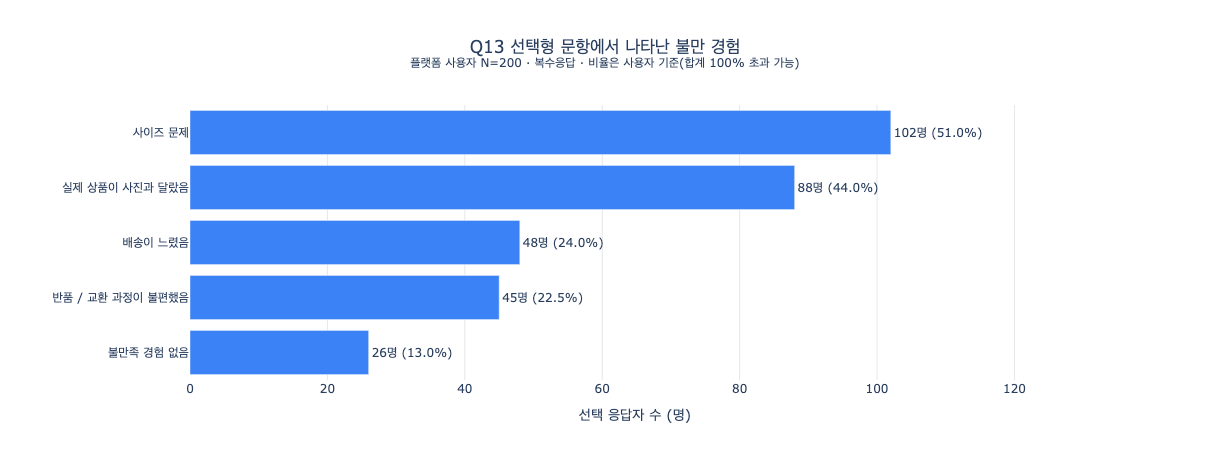

In [9]:
# Q13 선택형 복수응답: 플랫폼 사용자 200명을 분모로 응답 수와 선택률 표시
fig = go.Figure(go.Bar(
    x=q13_table['선택 응답자'].to_numpy(),
    y=q13_table.index.tolist(),
    orientation='h',
    marker_color=COLORS['view'],
    text=[f'{int(count)}명 ({pct:.1f}%)' for count, pct in
          zip(q13_table['선택 응답자'], q13_table['선택률 (%)'])],
    textposition='outside',
    cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.update_xaxes(title_text='선택 응답자 수 (명)',
                 range=[0, q13_table['선택 응답자'].max() * 1.27], gridcolor='#E5E7EB')
fig.update_yaxes(autorange='reversed')
fig.update_layout(
    title=dict(text=f'Q13 선택형 문항에서 나타난 불만 경험<br><sup>플랫폼 사용자 N={len(users)} · 복수응답 · 비율은 사용자 기준(합계 100% 초과 가능)</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    height=450, width=1000, margin=dict(l=190, r=130, t=105, b=70),
    showlegend=False,
)
fig.show()

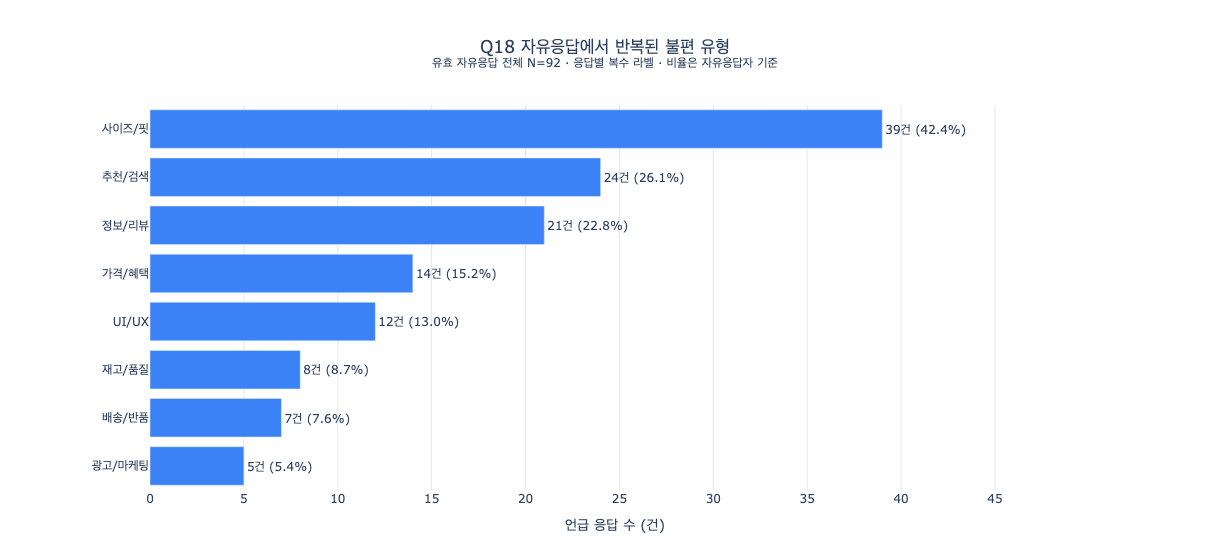

In [10]:
# 카테고리 막대를 전체 유효 자유응답 92건 기준으로 표시
fig = go.Figure(go.Bar(
    x=q18_types.values,
    y=q18_types.index,
    orientation='h',
    marker_color=COLORS['view'],
    text=[f'{count}건 ({count/q18_n:.1%})' for count in q18_types.values],
    textposition='outside',
    cliponaxis=False,
    hovertemplate='%{y}<br>%{text}<extra></extra>',
))
fig.update_xaxes(title_text='언급 응답 수 (건)',
                 range=[0, q18_types.max() * 1.27], gridcolor='#E5E7EB')
fig.update_yaxes(autorange='reversed')
fig.update_layout(
    title=dict(text=f'Q18 자유응답에서 반복된 불편 유형<br><sup>유효 자유응답 전체 N={q18_n} · 응답별 복수 라벨 · 비율은 자유응답자 기준</sup>', x=0.5),
    paper_bgcolor='white', plot_bgcolor='white',
    height=560, width=1000, margin=dict(l=150, r=130, t=105, b=70),
    showlegend=False,
)
fig.show()

### 후속 탐색 결과

선택형 Q13에서는 플랫폼 사용자 200명 중 102명(51.0%)이 사이즈 문제를 선택했다. 자유응답 Q18에서도 사이즈·핏이 유효 응답 92건 중 39건(42.4%)으로 가장 많이 언급됐고, 플랫폼 사용자 응답에서는 28/68건(41.2%)에서 나타났다.

질문 방식과 분모는 다르지만 두 문항에서 사이즈·핏이 반복적으로 나타나 **후속 UX 검증 후보**로 좁혔다. 두 비율은 같은 발생률 지표로 직접 비교하지 않는다.

### 설문 설계 회고

자유응답에는 Q13의 선택지에 없는 추천·검색, 가격·혜택, UI·UX 등의 주제도 있었다. 향후 설문을 설계할 때 문항 범위를 점검할 수 있다.

---
## 6. 해석 범위와 활용 방향

### 해석 범위

이 설문은 20대가 많은 편의표본으로 여러 패션 플랫폼 이용자의 응답을 모았다. Q15는 특정 하나의 플랫폼을 지정하지 않았고, Q14는 실제 잔류가 아닌 미래 이용 의향이다. H1의 병합 교차표에는 기대빈도 5 미만 셀이 1개 있어 카이제곱 검정은 보조 근거로 본다.

H2는 최근 6개월 구매자 191명의 자기보고 구매 빈도·최근성으로 계산했으며, 플랫폼 사용자 중 비구매자 9명은 포함하지 않았다. Q14는 가장 자주 사용하는 플랫폼, Q15는 현재 이용하는 패션 플랫폼, Q9·Q10은 패션 플랫폼 구매 전반을 물어 지시 대상도 완전히 같지 않다.

Q16·Q17은 선택지가 완전히 같지 않은 회상 응답이다. H3는 공통 3채널로 처음 인지한 155명의 응답 연결을 보여주며 실제 유입→구매 경로나 채널 어트리뷰션은 측정하지 않았다. Q13은 플랫폼 사용자 200명의 선택형 응답이고, Q18은 자발적 유효 자유응답 92건(그중 플랫폼 사용자 68건)이다. 질문 방식과 분모가 달라 두 비율을 하나의 발생률로 합치거나 사이즈·핏을 구매 감소의 원인으로 확정할 수 없다.

### 활용 방향

**추천 의향·이용·구매:** 추천 의향은 지속 이용 의향과 양의 관계였지만 비추천자 중에도 87.5%가 긍정 지속 의향을 답했고, 자기보고 구매 활동과의 관계는 약했다. 특정 플랫폼에서 같은 설문 응답과 재방문·구매·실제 잔류 또는 이탈 로그를 연결해 이 태도 차이가 행동에서도 나타나는지 확인한다.

**채널:** 최초 인지 채널별 동일 채널 응답률은 SNS·유튜브와 친구/지인에서 달랐다. 특정 서비스의 최초 유입 경로, 재방문 경로, 구매 직전 접점과 실제 구매를 연결해 인지와 구매 과정에서 각 채널의 역할을 확인한다.

**사이즈·핏:** Q13과 Q18에서 반복된 불편을 상품군별로 다시 확인한다. 상품 상세 조회→장바구니→구매와 사이즈 사유 반품·교환, 재구매를 연결해 실제 행동에서도 같은 문제가 나타나는 영역을 좁힌 뒤 UX 개선 대상을 구체화한다.